In [ ]:
%reset -f

import mne 
import numpy as ny
from scipy import signal
from scipy.signal import hilbert, chirp
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
%matplotlib inline
def get_data(path, sid):
    file = mne.io.read_raw('%s/data/%s.cdt.cnt'%(path, sid),preload=(True))
    events=mne.events_from_annotations(file)
    file.pick_types(eeg= True, stim = False)
    file.info['bads']
    file.filter(0.1, 30, phase= 'zero-double')
    file.set_eeg_reference(['A2','A1']) 
    file.pick_types(eeg= True, stim = True, exclude = ['VEOG', 'HEOG', 'Trigger',])
    picks = mne.pick_types(file.info, eeg= True, stim = False, exclude =['VEOG', 'HEOG','Trigger']) 
    trial = np.array(pd.read_csv('%s/data/%s.csv'%(path, sid))['trial_no'])
    trial = trial +1
    events[0][:,2] = trial
    file.set_montage('standard_1005')
    return file, events[0] ,trial

def ica_process(file):
    ica = mne.preprocessing.ICA(n_components=9, random_state=97)
    raw_1 = file.copy()
    ica.fit(raw_1)
    ica.plot_sources(file)
    ica.plot_components()
    return ica

def ica_exclude(ica, file, n_exclude):
    ica.plot_overlay(file, exclude=n_exclude, picks='eeg')
    ica.exclude = n_exclude
    ica.apply(file)


def sound_filter(input_sound):
    cutoff_freq = 512  
    fs = 44100  
    order = 4  
    nyq = 0.5 * fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    filtered_data = filtfilt(b, a, input_sound)
    return filtered_data

def resample(input_sound):
    number_of_samples = round(len(input_sound) * float(1024) / 44100)
    resampled_data = signal.resample(input_sound, number_of_samples)
    resampled_data = resampled_data.astype(input_sound.dtype)
    return resampled_data

def get_envelope(path, sid, trial):
    sound = [wavfile.read('%s/sound/%s/%s.wav'%(path, sid,i))[1] for i in trial]
    filter_sound = [sound_filter(sound) for sound in sound]
    resample_sound = [resample(i) for i in filter_sound]
    envelope = [np.abs(hilbert(i)) for i in resample_sound]
    nor_envelope= [(envelope[i]-envelope[i].min())/(envelope[i].max()-envelope[i].min()) for i in range(len(envelope))]
    return nor_envelope

def sound_filter_2(input_sound):
    cutoff_freq = 125  
    fs = 44100  
    order = 4  
    nyq = 0.5 * fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    filtered_data = filtfilt(b, a, input_sound)
    return filtered_data

def resample_2(input_sound):
    number_of_samples = round(len(input_sound) * float(250) / 44100)
    resampled_data = signal.resample(input_sound, number_of_samples)
    resampled_data = resampled_data.astype(input_sound.dtype)
    return resampled_data

def get_envelope_2(path, sid, trial):
    sound = [wavfile.read('%s/sound/%s/%s.wav'%(path, sid,i))[1] for i in trial]
    filter_sound = [sound_filter_2(sound) for sound in sound]
    resample_sound = [resample_2(i) for i in filter_sound]
    envelope = [np.abs(hilbert(i)) for i in resample_sound]
    nor_envelope= [(envelope[i]-envelope[i].min())/(envelope[i].max()-envelope[i].min()) for i in range(len(envelope))]
    return nor_envelope

In [2]:
path='E:/535505/assignment_1/'
sid='training-5'
file, event, trial = get_data(path, sid)
print("Sampling rate:", file.info['sfreq'])

Reading 0 ... 1692927  =      0.000 ...  1653.249 secs...
Used Annotations descriptions: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '4', '5', '6', '7', '8', '9']
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-12 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-12 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Sampling rate: 1024.0


Using matplotlib as 2D backend.


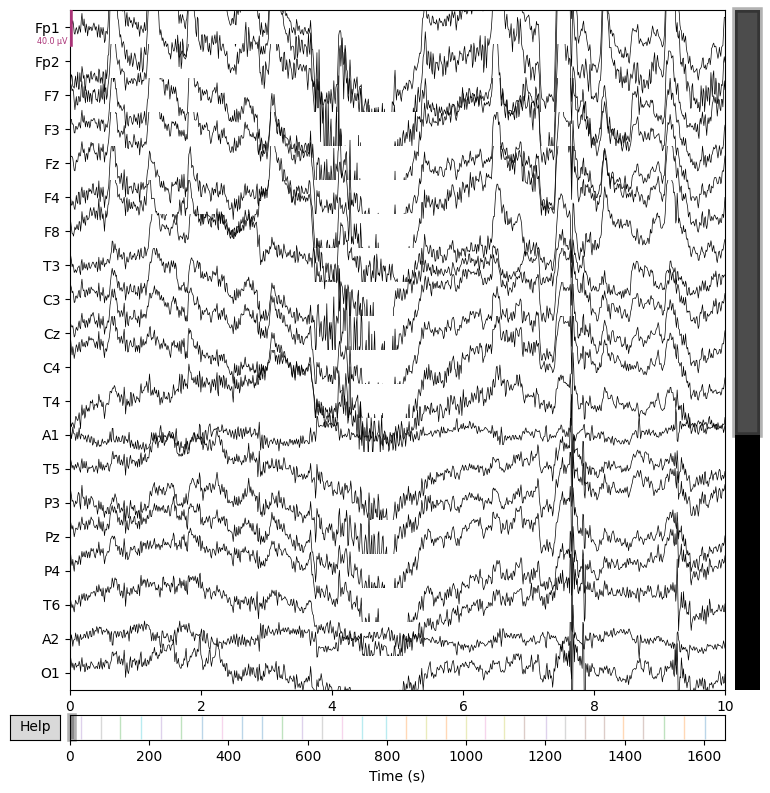

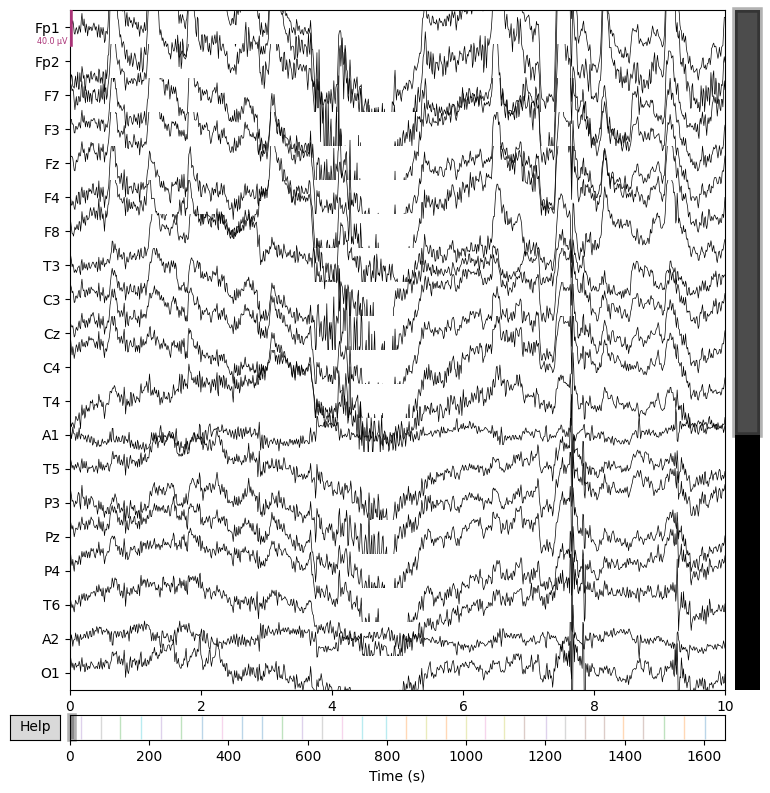

In [3]:
file.plot()

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 9 components
Fitting ICA took 19.4s.
Creating RawArray with float64 data, n_channels=9, n_times=1692928
    Range : 0 ... 1692927 =      0.000 ...  1653.249 secs
Ready.


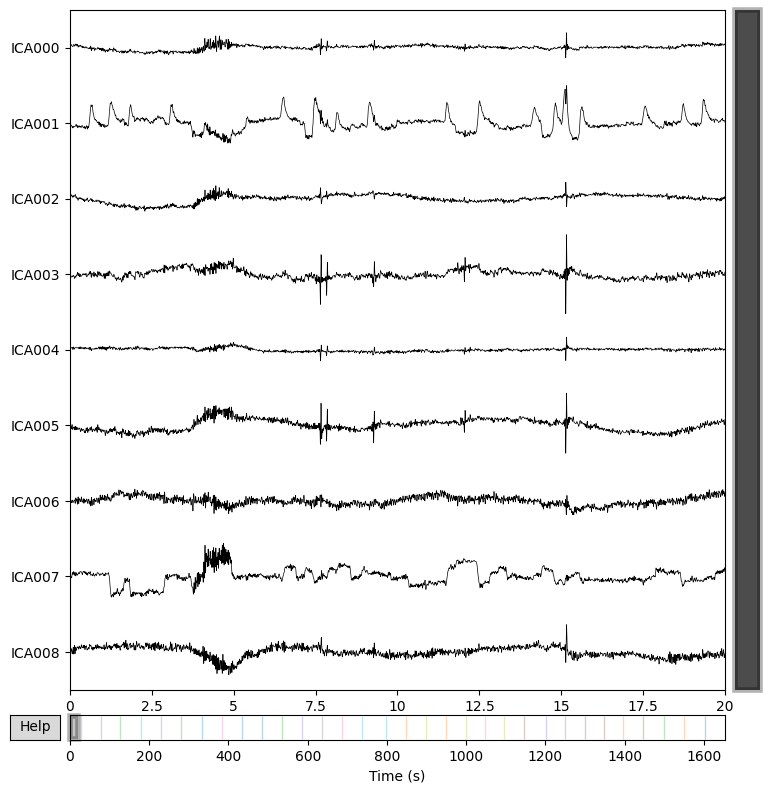

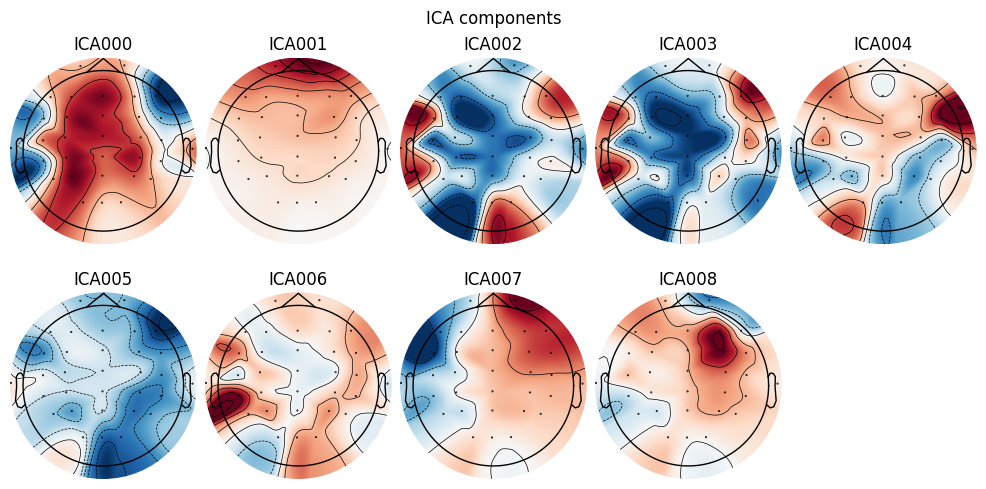

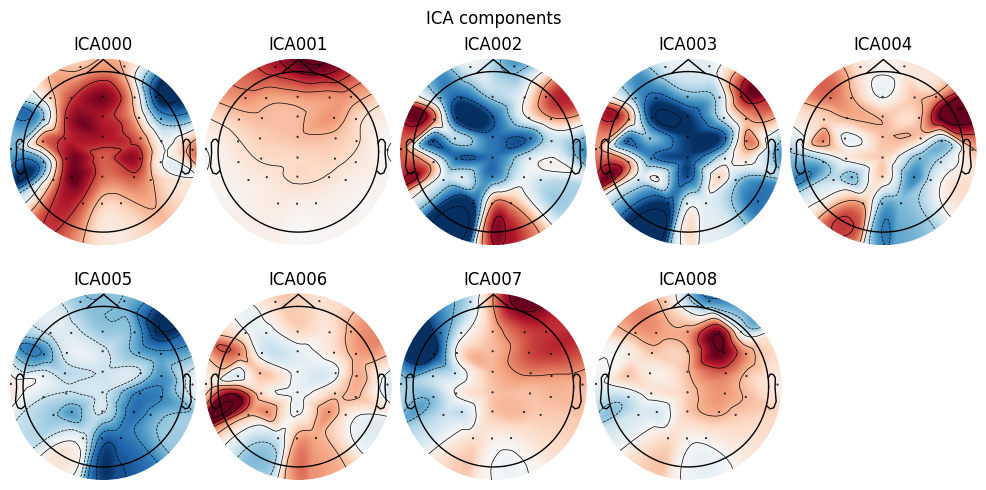

In [4]:
ica = mne.preprocessing.ICA(n_components=9, random_state=97)
ica.fit(file)
ica.plot_sources(file)
ica.plot_components()

Applying ICA to Raw instance
    Transforming to ICA space (9 components)
    Zeroing out 4 ICA components
    Projecting back using 32 PCA components


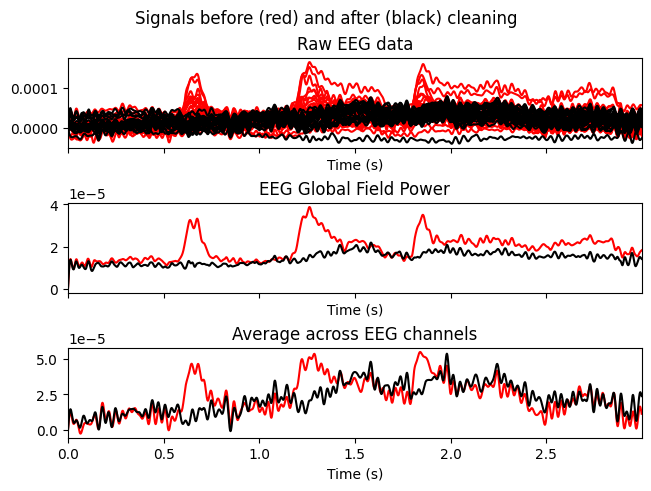

Applying ICA to Raw instance
    Transforming to ICA space (9 components)
    Zeroing out 4 ICA components
    Projecting back using 32 PCA components


In [5]:
ica_exclude(ica, file, n_exclude=[0,1,8,7])

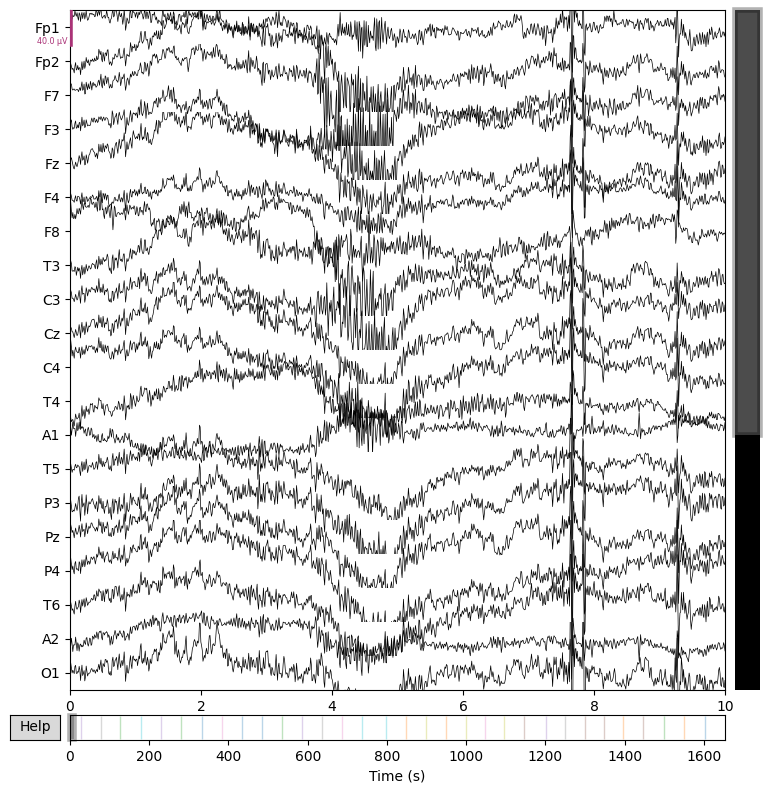

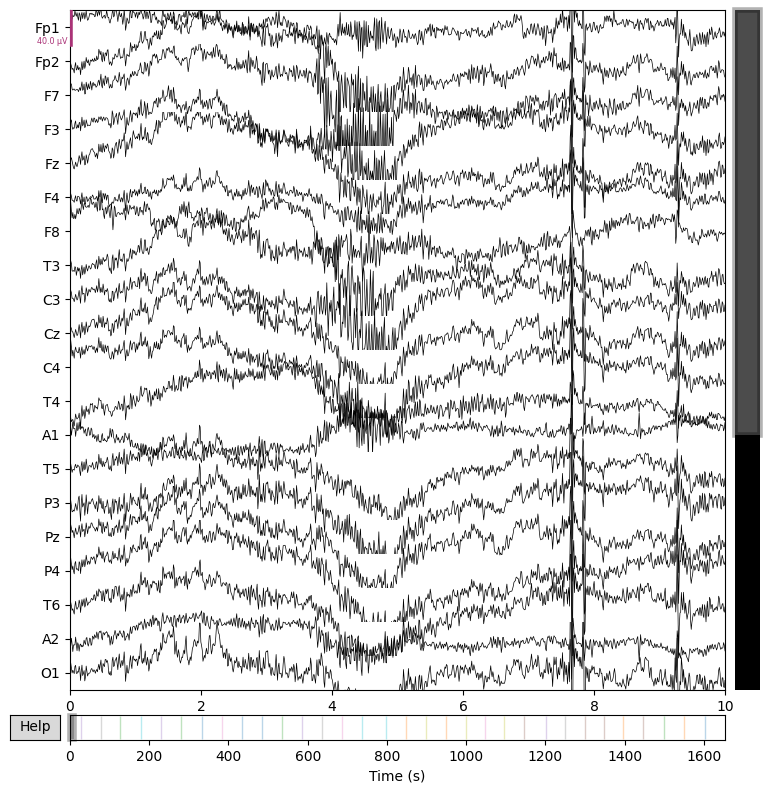

In [6]:
file.plot()

In [ ]:
file.pick_types(eeg= True, stim = True, exclude = ['VEOG', 'HEOG', 'Trigger','A1','A2'])
picks = mne.pick_types(file.info, eeg= True, stim = False, exclude =['VEOG', 'HEOG','Trigger','A1','A2']) 
label = [[1,0] if i <= 16 else [0,1] for i in trial]
nor_envelope = get_envelope(path, sid, trial)
eeg_data = [file.get_data()[:,int(event[i,0]):int(event[i,0]+len(nor_envelope[i]))] for i in range(len(trial))]
dataset = np.array([eeg_data, nor_envelope, label], dtype=object)
for i in range(32):
    print(eeg_data[i].shape, nor_envelope[i].shape)
np.save('%s/data/%s_dataset.npy'%(path,sid), dataset)
print("NPY saved!")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
(30, 11102) (11102,)
(30, 11090) (11090,)
(30, 11182) (11182,)
(30, 11142) (11142,)
(30, 11102) (11102,)
(30, 11082) (11082,)
(30, 11062) (11062,)
(30, 11062) (11062,)
(30, 11182) (11182,)
(30, 10970) (10970,)
(30, 11060) (11060,)
(30, 11162) (11162,)
(30, 11094) (11094,)
(30, 11130) (11130,)
(30, 11122) (11122,)
(30, 11022) (11022,)
(30, 11082) (11082,)
(30, 11102) (11102,)
(30, 11182) (11182,)
(30, 11040) (11040,)
(30, 11162) (11162,)
(30, 11054) (11054,)
(30, 11092) (11092,)
(30, 11042) (11042,)
(30, 11102) (11102,)
(30, 11122) (11122,)
(30, 11142) (11142,)
(30, 11082) (11082,)
(30, 11102) (11102,)
(30, 11142) (11142,)
(30, 11090) (11090,)
(30, 11102) (11102,)
NPY saved!


In [ ]:
file.pick_types(eeg= True, stim = True, exclude = ['VEOG', 'HEOG', 'Trigger','A1','A2'])
picks = mne.pick_types(file.info, eeg= True, stim = False, exclude =['VEOG', 'HEOG','Trigger','A1','A2']) 
label = [[1,0] if i <= 16 else [0,1] for i in trial]
nor_envelope = get_envelope(path, sid, trial)
eeg_data = [file.get_data()[:,int(event[i,0]):int(event[i,0]+len(nor_envelope[i]))] for i in range(len(trial))]
dataset = np.array([eeg_data, nor_envelope, label], dtype=object)
for i in range(32):
    print(eeg_data[i].shape, nor_envelope[i].shape)
np.save('%s/data/%s_dataset_250.npy'%(path,sid), dataset)
print("NPY 250Hz saved!")